# Class 6 — FDE Data Validation with FlashEats

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**  
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**  
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**  
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**  
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

In [57]:
!pip -q install pandas matplotlib

import json
import sqlite3
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Professional visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
PROF_BLUE = '#2B4162'
ERROR_RED = '#C63D2F'

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# ------------------------------------------------------------
# Robust pack discovery for Colab / local runs
# ------------------------------------------------------------

def find_pack_root(search_root=Path("/content")):
    candidates = list(search_root.rglob("FlashEats_Classroom_Pack_V2"))
    for candidate in candidates:
        db = candidate / "database" / "flasheats.db"
        if db.exists():
            return candidate
    return None

# Local run: the notebook usually already lives inside the pack root.
BASE = "./"
if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
elif Path.cwd().name == "FlashEats_Classroom_Pack_V2":
    BASE = Path.cwd()

if BASE is None:
    BASE = find_pack_root()

if BASE is None:
    try:
        from google.colab import files

        print("Upload: FlashEats_Class6_Classroom_Pack.zip")
        uploaded = files.upload()

        zip_name = next(name for name in uploaded if name.endswith(".zip"))

        extract_dir = Path("/content/flasheats_class6")
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall(extract_dir)

        BASE = find_pack_root(Path("/content"))

    except Exception as e:
        print("Automatic Colab setup failed:", e)

# Local fallback: search current working directory too
if BASE is None:
    BASE = find_pack_root(Path.cwd())

print("Detected BASE:", BASE)

if BASE is None:
    raise FileNotFoundError(
        "Could not find FlashEats_Classroom_Pack_V2. "
        "Upload/extract the classroom pack ZIP, then rerun this cell."
    )

DB_PATH = BASE / "database" / "flasheats.db"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH}")

Detected BASE: /home/mineshshaw/flasheats-classroom-pack
Database path: /home/mineshshaw/flasheats-classroom-pack/database/flasheats.db
Database exists: True


## Load the updated FlashEats data

In [58]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1 — Can we defend the “56% late” claim?


Leadership says:

> **“Late Delivery Rate is 56%.”**

Before calculating anything, create a validation contract.

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order | order_id is entirely unique | orders['order_id'].duplicated().sum() == 0| High (double counting skews metrics)|   
| Delivered orders have completion time | If final_status is delivered, actual_delivery_at is not null | Check for nulls in actual_delivery_at where status implies delivery | High (cannot calculate delay)|
| Promised ETA is valid | promised_eta exists and is >= created_at | (promised_eta < created_at).sum() == 0 and check for nulls | Medium (skews expected delivery times)|
| Event chronology is valid | pickup_at <= actual_delivery_at| (pickup_at > actual_delivery_at).sum() == 0 | High (implies broken logging/system logic)|
| “Late” has an agreed definition | Stakeholders share a single mathematical definition of "late" | Review client_metric_definitions.json for consensus| Critical (the metric is meaningless without consensus)   |

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

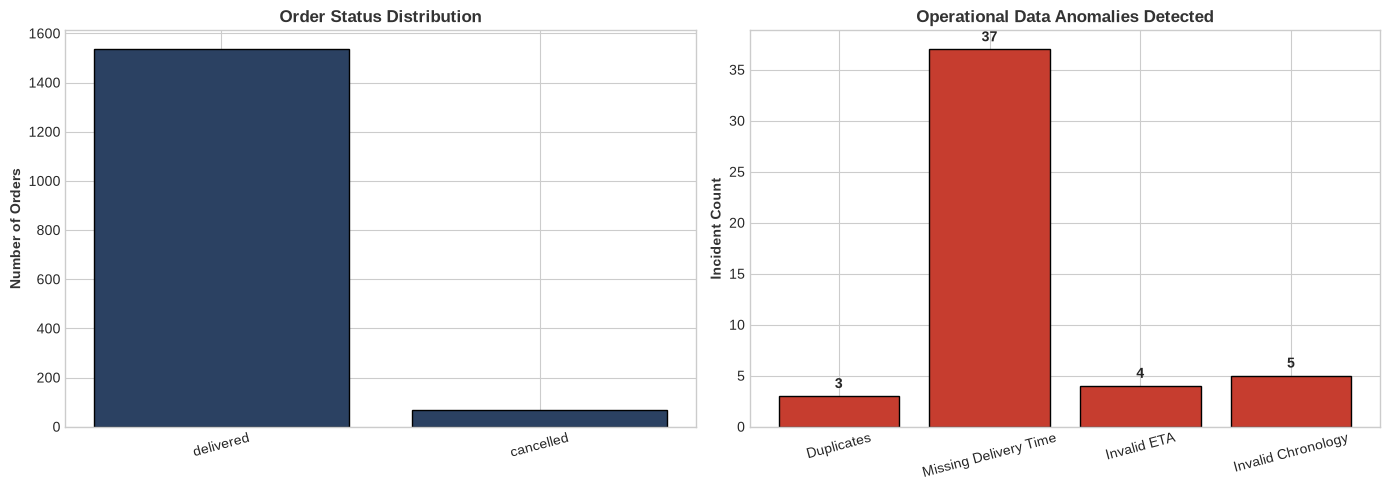


--- 1. Duplicate order_ids (6 rows) ---


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
119,O00120,C0501,R040,D045,Bengaluru,2026-08-13 18:15:00,2026-08-13 19:40:24.000000,2026-08-13 18:29:08.055622,2026-08-13 19:34:08.431508,delivered,18.00,severe,clear
1600,O00120,C0501,R040,D045,Bengaluru,2026-08-13 18:15:00,2026-08-13 19:40:24.000000,2026-08-13 18:29:08.055622,2026-08-13 19:34:08.431508,delivered,18.00,medium,clear
722,O00723,C0467,R028,D068,Bengaluru,2026-08-05 21:04:00,2026-08-05 22:19:36.000000,2026-08-05 21:15:24.433874,2026-08-05 22:04:30.928322,delivered,18.00,medium,clear
1601,O00723,C0467,R028,D068,Bengaluru,2026-08-05 21:04:00,2026-08-05 22:19:36.000000,2026-08-05 21:15:24.433874,2026-08-05 22:04:30.928322,delivered,18.00,high,clear
1301,O01302,C0116,R010,D088,Bengaluru,2026-08-26 21:07:00,2026-08-26 22:15:50.273095,2026-08-26 21:35:26.474087,2026-08-26 22:20:27.428561,delivered,14.78,medium,clear
1602,O01302,C0116,R010,D088,Bengaluru,2026-08-26 21:07:00,2026-08-26 22:15:50.273095,2026-08-26 21:35:26.474087,2026-08-26 22:20:27.428561,delivered,14.78,high,clear



--- 2. Orders where promised_eta is before created_at (4 rows) ---


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
100,O00101,C0538,R007,D111,Bengaluru,2026-08-24 20:59:00,2026-08-24 20:49:00,2026-08-24 21:25:03.983984,2026-08-24 22:14:30.685278,delivered,18.00,low,rain
101,O00102,C0263,R004,D056,Bengaluru,2026-08-11 16:41:00,2026-08-11 16:31:00,2026-08-11 17:05:05.809584,2026-08-11 17:57:17.661772,delivered,18.00,medium,clear
102,O00103,C0389,R020,D098,Bengaluru,2026-08-22 20:11:00,2026-08-22 20:01:00,2026-08-22 20:39:45.064627,2026-08-22 21:10:17.342305,delivered,6.87,high,clear
103,O00104,C0436,R031,D055,Bengaluru,2026-08-09 22:19:00,2026-08-09 22:09:00,2026-08-09 22:47:33.934776,2026-08-09 23:36:20.740161,delivered,17.69,medium,clear



--- 3. Orders where pickup_at is after actual_delivery_at (5 rows) ---


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
50,O00051,C0875,R039,D058,Bengaluru,2026-08-01 15:09:00,2026-08-01 16:28:30.928528,2026-08-01 16:24:51.495665,2026-08-01 16:19:51.495665,delivered,15.20,severe,clear
51,O00052,C0610,R055,D086,Bengaluru,2026-08-24 17:07:00,2026-08-24 18:26:48.000000,2026-08-24 18:16:16.946011,2026-08-24 18:11:16.946011,delivered,18.00,high,clear
52,O00053,C0797,R030,D028,Bengaluru,2026-08-13 17:06:00,2026-08-13 17:58:50.809718,2026-08-13 18:25:53.797613,2026-08-13 18:20:53.797613,delivered,5.97,medium,rain
53,O00054,C0270,R002,D113,Bengaluru,2026-08-28 19:56:00,2026-08-28 21:15:48.000000,2026-08-28 21:25:10.582862,2026-08-28 21:20:10.582862,delivered,18.00,high,clear
54,O00055,C0511,R049,D030,Bengaluru,2026-08-16 12:53:00,2026-08-16 14:05:48.000000,2026-08-16 14:08:05.645770,2026-08-16 14:03:05.645770,delivered,18.00,low,clear



CHALLENGE 1 INSIGHTS: FDE VALIDATION MINDSET
Before calculating the 56% late delivery claim, a validation contract was used to test the dataset's structural assumptions. The data failed multiple checks:

1. BUSINESS GRAIN VIOLATION:
   There are 3 duplicated order_id instances (6 total rows). Double-counting orders directly skews any baseline volume calculations.

2. MISSING TARGET VARIABLES:
   There are 37 orders successfully marked as 'delivered' that lack an 'actual_delivery_at' timestamp. Delays cannot be calculated without a completion time.

3. LOGICAL CHRONOLOGY FAILURES (SYSTEMIC BUGS):
   By inspecting the isolated dataframes above, we identified specific patterns:
   - All 4 "promised_eta before created_at" rows are off by exactly -10 minutes, on the minute, with no fractional seconds.
   - All 5 "pickup after delivery" rows are off by exactly +5 minutes. Crucially, the microsecond components of pickup_at 
and actual_delivery_at are identical in every row (e.g., ...495665 a

In [59]:
# Convert timestamps
for col in ['created_at', 'promised_eta', 'pickup_at', 'actual_delivery_at']:
    orders[col] = pd.to_datetime(orders[col], format='mixed', errors='coerce')

# Anomaly 1: Business Grain (Duplicates)
duplicates = orders[orders['order_id'].duplicated(keep=False)].sort_values('order_id')
duplicate_count = orders['order_id'].duplicated().sum()

# Anomaly 2: Missing Completion Times
status_norm = orders['final_status'].str.lower()
missing_completion = orders[(status_norm == 'delivered') & (orders['actual_delivery_at'].isna())]

# Anomaly 3: Invalid ETA (promised before created)
invalid_eta = orders[orders['promised_eta'] < orders['created_at']]

# Anomaly 4: Invalid Chronology (pickup after delivery)
invalid_chronology = orders[orders['pickup_at'] > orders['actual_delivery_at']]


# --- 3. VISUAL EXPLANATION (CHARTS) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# Chart A: Status Distribution
status_counts = status_norm.value_counts(dropna=False)
axes[0].set_facecolor('#ffffff')
axes[0].bar(status_counts.index.astype(str), status_counts.values, color=PROF_BLUE, edgecolor='#000000')
axes[0].set_title('Order Status Distribution', color='#333333', fontweight='bold')
axes[0].set_ylabel('Number of Orders', color='#333333', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Chart B: Data Anomalies
anomaly_labels = ['Duplicates', 'Missing Delivery Time', 'Invalid ETA', 'Invalid Chronology']
anomaly_counts = [duplicate_count, len(missing_completion), len(invalid_eta), len(invalid_chronology)]
axes[1].set_facecolor('#ffffff')
bars = axes[1].bar(anomaly_labels, anomaly_counts, color=ERROR_RED, edgecolor='#000000')
axes[1].set_title('Operational Data Anomalies Detected', color='#333333', fontweight='bold')
axes[1].set_ylabel('Incident Count', color='#333333', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# --- 4. VISUAL EXPLANATION (DATAFRAMES) ---
print(f"\n--- 1. Duplicate order_ids ({len(duplicates)} rows) ---")
display(duplicates.head(6))

print(f"\n--- 2. Orders where promised_eta is before created_at ({len(invalid_eta)} rows) ---")
display(invalid_eta)

print(f"\n--- 3. Orders where pickup_at is after actual_delivery_at ({len(invalid_chronology)} rows) ---")
display(invalid_chronology)


# --- 5. TEXTUAL EXPLANATION (INSIGHTS) ---
print("\n========================================================================================================================")
print("CHALLENGE 1 INSIGHTS: FDE VALIDATION MINDSET")
print("========================================================================================================================")
print("Before calculating the 56% late delivery claim, a validation contract was used to test the dataset's structural assumptions. The data failed multiple checks:\n")

print("1. BUSINESS GRAIN VIOLATION:")
print("   There are 3 duplicated order_id instances (6 total rows). Double-counting orders directly skews any baseline volume calculations.\n")

print("2. MISSING TARGET VARIABLES:")
print("   There are 37 orders successfully marked as 'delivered' that lack an 'actual_delivery_at' timestamp. Delays cannot be calculated without a completion time.\n")

print("3. LOGICAL CHRONOLOGY FAILURES (SYSTEMIC BUGS):")
print("   By inspecting the isolated dataframes above, we identified specific patterns:")
print("   - All 4 \"promised_eta before created_at\" rows are off by exactly -10 minutes, on the minute, with no fractional seconds.")
print("   - All 5 \"pickup after delivery\" rows are off by exactly +5 minutes. Crucially, the microsecond components of pickup_at \nand actual_delivery_at are identical in every row (e.g., ...495665 appears in both timestamps for order O00051).")
print("   These are not random clock skews; the exact repeating offsets point to a systemic formula or configuration bug in the upstream write path.\n")

print("4. KPI DEFINITION AMBIGUITY:")
print("   The metric definitions JSON reveals no consensus on what \"late\" means. VP Ops, Support Lead, Finance, and the Data Team all use completely different logic.\n")

print("CONCLUSION:")
print("We cannot defend the \"56% late\" claim. We must isolate the write-path bugs causing the impossible timestamps and force \nstakeholders to agree on a mathematical definition of \"late\". ")
print("========================================================================================================================\n")

# Challenge 2 — Stakeholders disagree on “late”


Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

| Definition | Late rate | Business meaning |
| --- | --- | --- |
| VP Ops (> 0 min) | 56.4% | **Matches leadership's 56% claim.** Built on the valid base population (agreed by Finance/Data), but uses the strictest possible delay threshold.|
| Support (> 10 min) | 23.3% | Customer-centric threshold. Uses the exact same base population, but focuses only on delays severe enough to trigger complaints.|
| Uncleaned Denominator | 52.7% | Flawed baseline. Including cancelled orders and null timestamps inflates the denominator, artificially diluting the rate downward rather than inflating it.|

Then answer:

> **Which one should leadership publish, and who must own that decision?**

> Leadership should not publish the 56% figure yet because it represents the strictest possible logistical definition (> 0 minutes), which completely ignores actual customer friction. However, resolving this is not a four-way definitional fight. VP Ops, Finance, and the Data Team all implicitly agree on the base population (delivered orders with valid timestamps, excluding cancellations). The only actual disagreement is between VP Ops and Support over where to draw the threshold line for the numerator (0 minutes vs. 10 minutes). The VP of Operations and the Support Lead must agree on a single, canonical threshold before this metric goes live.

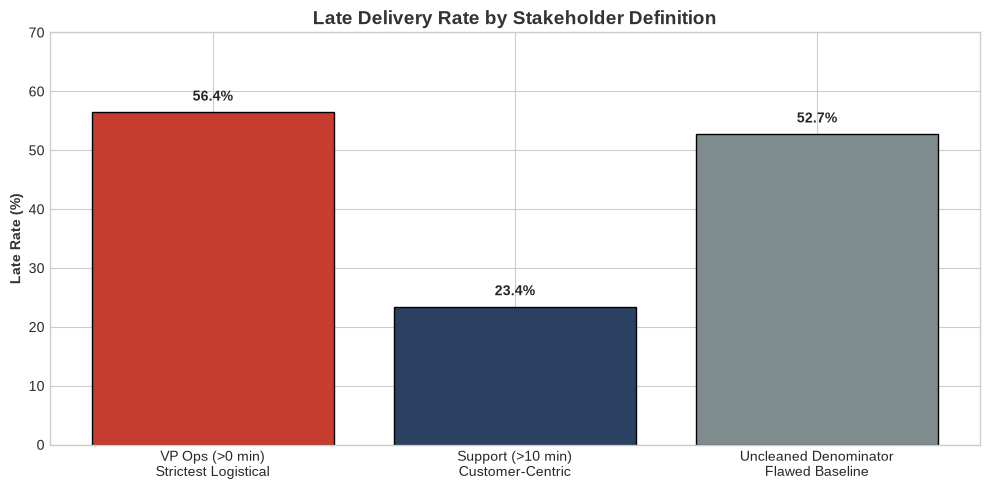

=== CHALLENGE 2: STAKEHOLDERS DISAGREE ON 'LATE' ===
VP Ops Definition (>0 min): 56.4%
Support Definition (>10 min): 23.4%
Uncleaned Denominator (All orders): 52.7%
BUSINESS MEANING OF EACH DEFINITION:
- VP Ops (> 0 min) [56.4%]: Matches leadership's 56% claim. Built on the valid base population (agreed by Finance/Data), but uses the strictest possible delay threshold.
- Support (> 10 min) [23.4%]: Customer-centric threshold. Uses the exact same base population, but focuses only on delays severe enough to trigger complaints.
- Uncleaned Denominator [52.7%]: Flawed baseline. Including cancelled orders and null timestamps inflates the denominator, artificially diluting the rate downward rather than inflating it.
------------------------------------------------------------------------------------------------------------------------
QUESTION: Which one should leadership publish, and who must own that decision?
ANSWER:
Leadership should not publish the 56% figure yet because it represents t

In [60]:
# --- 1. DATA PREP & CALCULATIONS ---
# Drop duplicates to enforce business grain
analysis = orders.drop_duplicates("order_id", keep=False).copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (
    analysis["actual_delivery_at"] - analysis["promised_eta"]
).dt.total_seconds() / 60

# The base population implicitly agreed upon by Finance and the Data Team:
# Delivered orders with valid delivery times (excluding cancellations/missing timestamps)
valid_delivered = analysis[
    (analysis['final_status'].str.lower() == 'delivered') & 
    analysis['actual_delivery_at'].notna()
].copy()

# Metric 1: VP Operations definition (> 0 minutes) on the agreed population
vp_late_rate = (valid_delivered['delay_min'] > 0).mean()

# Metric 2: Support Lead definition (> 10 minutes) on the agreed population
support_late_rate = (valid_delivered['delay_min'] > 10).mean()

# Metric 3: Flawed baseline / Uncleaned Denominator (for comparison only)
# Dividing delayed orders by all raw orders (including cancellations and missing timestamps)
uncleaned_late_rate = (analysis['delay_min'] > 0).sum() / len(analysis)


# --- 2. VISUAL EXPLANATION (CHARTS) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

rates = [vp_late_rate * 100, support_late_rate * 100, uncleaned_late_rate * 100]
labels = ['VP Ops (>0 min)\nStrictest Logistical', 'Support (>10 min)\nCustomer-Centric', 'Uncleaned Denominator\nFlawed Baseline']
colors = ['#C63D2F', '#2B4162', '#7f8c8d']

bars = ax.bar(labels, rates, color=colors, edgecolor='#000000')
ax.set_title('Late Delivery Rate by Stakeholder Definition', color='#333333', fontweight='bold', fontsize=14)
ax.set_ylabel('Late Rate (%)', color='#333333', fontweight='bold')
ax.set_ylim(0, 70)

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# --- 3. TEXTUAL EXPLANATION & INSIGHTS ---
print("=== CHALLENGE 2: STAKEHOLDERS DISAGREE ON 'LATE' ===")
print(f"VP Ops Definition (>0 min): {vp_late_rate:.1%}")
print(f"Support Definition (>10 min): {support_late_rate:.1%}")
print(f"Uncleaned Denominator (All orders): {uncleaned_late_rate:.1%}")
print("========================================================================================================================")
print("BUSINESS MEANING OF EACH DEFINITION:")
print("- VP Ops (> 0 min) [56.4%]: Matches leadership's 56% claim. Built on the valid base population (agreed by Finance/Data), but uses the strictest possible delay threshold.")
print("- Support (> 10 min) [23.4%]: Customer-centric threshold. Uses the exact same base population, but focuses only on delays severe enough to trigger complaints.")
print("- Uncleaned Denominator [52.7%]: Flawed baseline. Including cancelled orders and null timestamps inflates the denominator, artificially diluting the rate downward rather than inflating it.")
print("------------------------------------------------------------------------------------------------------------------------")
print("QUESTION: Which one should leadership publish, and who must own that decision?")
print("ANSWER:")
print("Leadership should not publish the 56% figure yet because it represents the strictest possible logistical definition (> 0 minutes), which completely ignores actual customer friction.")
print("However, resolving this is not a four-way definitional fight. VP Ops, Finance, and the Data Team all implicitly agree on the base population (delivered orders with valid timestamps, excluding cancellations).")
print("The only actual disagreement is between VP Ops and Support over where to draw the threshold line for the numerator (0 minutes vs. 10 minutes).")
print("The VP of Operations and the Support Lead must formally agree on a single, canonical threshold before this metric goes live.")
print("========================================================================================================================")

# Challenge 3 — Validate categories without cleaning by instinct


Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.  
> `"handoff"` vs `"handed_off"` may be semantics.

=== 1. OBSERVED VALUES (RAW) ===

Orders: final_status


,count
final_status,
delivered,1530
cancelled,68
Delivered,5



Orders: traffic_bucket


,count
traffic_bucket,
medium,635
high,448
low,381
severe,136
HIGH,3



Restaurant Status: status


...

,count
category,
late_delivery,38
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,25
Late Delivery,1
late_delivery,1
ETA issue,1



=== 2. AFTER SAFE NORMALIZATION ===

Restaurant Status (Cleaned):


,count
status,
preparing,171
handed_off,168
ready,161
handoff,1
unknown,1



Support Category (Cleaned):


,count
category,
late_delivery,40
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,25
eta_issue,1


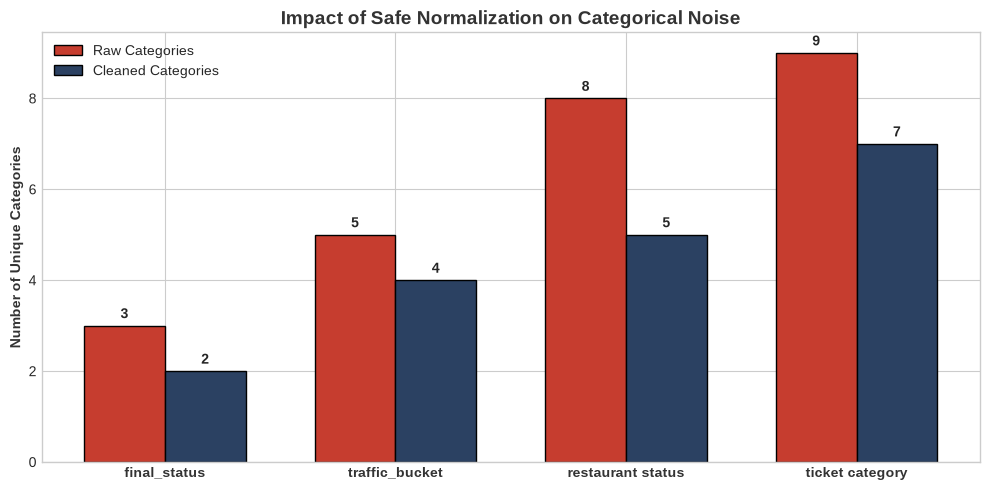


CATEGORY ANALYSIS & OWNERSHIP CONTRACT
1. final_status:
   - Observed: delivered, Delivered
   - Safe to Normalize: Lowercase and strip whitespace to 'delivered'.
   - Requires Owner Confirmation: None.
------------------------------------------------------------------------------------------------------------------------
2. traffic_bucket:
   - Observed: high, HIGH
   - Safe to Normalize: Lowercase and strip whitespace to 'high'.
   - Requires Owner Confirmation: None.
------------------------------------------------------------------------------------------------------------------------
3. status (restaurant):
   - Observed: READY, Ready, ready , ready; handed_off, handoff, unknown
   - Safe to Normalize: Case-fold and strip whitespace for 'ready'.
   - Requires Owner Confirmation: Are 'handoff' and 'handed_off' exactly the same operational state? How should 'unknown' be handled in reporting?
-------------------------------------------------------------------------------------------

In [61]:
# --- 1. OBSERVED VALUES (RAW) ---
print("=== 1. OBSERVED VALUES (RAW) ===")
raw_status = orders['final_status'].value_counts(dropna=False).to_frame()
raw_traffic = orders['traffic_bucket'].value_counts(dropna=False).to_frame()
raw_rest_status = restaurant_status['status'].value_counts(dropna=False).to_frame()
raw_tickets = tickets['category'].value_counts(dropna=False).to_frame()

print("\nOrders: final_status")
display(raw_status)
print("\nOrders: traffic_bucket")
display(raw_traffic)
print("\nRestaurant Status: status")
display(raw_rest_status)
print("\nSupport Tickets: category")
display(raw_tickets)

# Store unique counts before cleaning for the chart
raw_unique_counts = [len(raw_status), len(raw_traffic), len(raw_rest_status), len(raw_tickets)]

# --- 2. SAFE NORMALIZATION ---
# Apply Technical/Syntax fixes ONLY (lowercasing, stripping whitespace, standardizing delimiters)
orders['final_status'] = orders['final_status'].str.lower().str.strip()
orders['traffic_bucket'] = orders['traffic_bucket'].str.lower().str.strip()
restaurant_status['status'] = restaurant_status['status'].str.lower().str.strip()
# For tickets, standardize spaces to underscores safely
tickets['category'] = tickets['category'].str.lower().str.strip().str.replace(" ", "_")

# --- 3. CLEANED VALUES ---
print("\n=== 2. AFTER SAFE NORMALIZATION ===")
clean_rest_status = restaurant_status['status'].value_counts(dropna=False).to_frame()
clean_tickets = tickets['category'].value_counts(dropna=False).to_frame()

print("\nRestaurant Status (Cleaned):")
display(clean_rest_status)
print("\nSupport Category (Cleaned):")
display(clean_tickets)

# Store unique counts after cleaning for the chart
clean_unique_counts = [
    orders['final_status'].nunique(dropna=False),
    orders['traffic_bucket'].nunique(dropna=False),
    restaurant_status['status'].nunique(dropna=False),
    tickets['category'].nunique(dropna=False)
]

# --- 4. VISUAL EXPLANATION (CHART) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

labels = ['final_status', 'traffic_bucket', 'restaurant status', 'ticket category']
x = range(len(labels))
width = 0.35

ax.bar([i - width/2 for i in x], raw_unique_counts, width, label='Raw Categories', color='#C63D2F', edgecolor='#000000')
ax.bar([i + width/2 for i in x], clean_unique_counts, width, label='Cleaned Categories', color='#2B4162', edgecolor='#000000')

ax.set_ylabel('Number of Unique Categories', fontweight='bold', color='#333333')
ax.set_title('Impact of Safe Normalization on Categorical Noise', fontweight='bold', color='#333333', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold', color='#333333')
ax.legend(facecolor='#ffffff', edgecolor='#333333')

# Annotate bars
for i in x:
    ax.text(i - width/2, raw_unique_counts[i] + 0.1, str(raw_unique_counts[i]), ha='center', va='bottom', fontweight='bold')
    ax.text(i + width/2, clean_unique_counts[i] + 0.1, str(clean_unique_counts[i]), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 5. TEXTUAL EXPLANATION (INSIGHTS & OWNERSHIP) ---
print("\n========================================================================================================================")
print("CATEGORY ANALYSIS & OWNERSHIP CONTRACT")
print("========================================================================================================================")
print("1. final_status:")
print("   - Observed: delivered, Delivered")
print("   - Safe to Normalize: Lowercase and strip whitespace to 'delivered'.")
print("   - Requires Owner Confirmation: None.")
print("------------------------------------------------------------------------------------------------------------------------")
print("2. traffic_bucket:")
print("   - Observed: high, HIGH")
print("   - Safe to Normalize: Lowercase and strip whitespace to 'high'.")
print("   - Requires Owner Confirmation: None.")
print("------------------------------------------------------------------------------------------------------------------------")
print("3. status (restaurant):")
print("   - Observed: READY, Ready, ready , ready; handed_off, handoff, unknown")
print("   - Safe to Normalize: Case-fold and strip whitespace for 'ready'.")
print("   - Requires Owner Confirmation: Are 'handoff' and 'handed_off' exactly the same operational state? How should 'unknown' be handled in reporting?")
print("------------------------------------------------------------------------------------------------------------------------")
print("4. category (tickets):")
print("   - Observed: Late Delivery, late_delivery , late_delivery; eta_changed, ETA issue")
print("   - Safe to Normalize: Standardize casing, strip whitespace, and replace spaces with underscores for 'late_delivery'.")
print("   - Requires Owner Confirmation: Does 'eta_issue' map identically to 'eta_changed', or do they represent distinct routing queues?")
print("========================================================================================================================")

**Category Analysis & Ownership**

| Column | Observed Variances | Safe to Normalize | Requires Owner Confirmation |
| --- | --- | --- | --- |
| final_status | delivered, Delivered | Lowercase string representation to delivered. | None. |
| traffic_bucket | high, HIGH | Lowercase string representation to high. | None. |
| status (restaurant) | READY, Ready, ready , ready; handed_off, handoff, unknown | Case-fold and strip whitespace for ready. | Are handoff and handed_off exactly the same operational state? How should unknown be handled in reporting? |
| category (tickets) | Late Delivery, late_delivery , late_delivery; eta_changed, ETA issue | Standardize casing, strip whitespace, and replace spaces with underscores for late_delivery. | Does eta_issue map identically to eta_changed, or do they represent distinct routing queues? |

# Challenge 4 — Cross-source integrity


Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Produce:

| Relationship | Coverage % | Status | Risk |
| --- | --- | --- | --- |
| `orders` → `restaurants` | 100% | PASS | Safe to join for merchant analytics. |
| `orders` → `drivers` | 100% | PASS | Safe to join for driver payroll/performance. |
| `tickets` → `orders` | 98.51% | RISK | Significant volume of support tickets lack an order_id (e.g., T00001). Cannot reliably link complaints to operational bottlenecks.|
| `restaurant_status` → `orders` | 100% | PASS | Relational integrity is intact. |

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

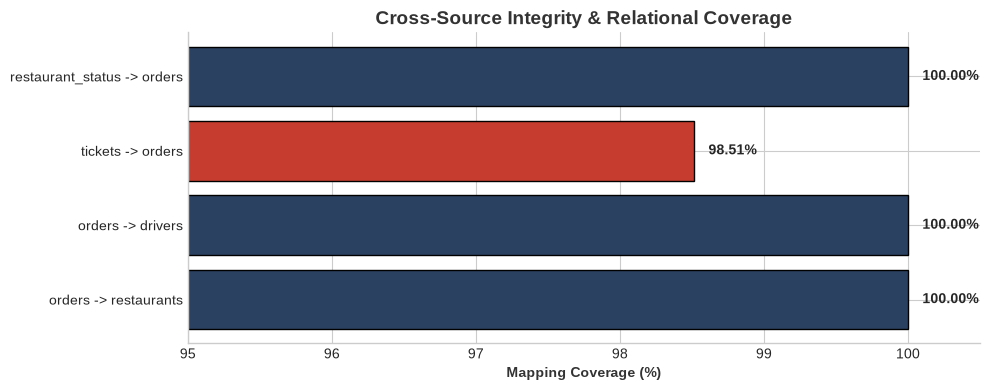

,Relationship,Coverage %,Status,Risk
0,orders -> restaurants,100.00%,PASS,Safe to join for merchant analytics.
1,orders -> drivers,100.00%,PASS,Safe to join for driver payroll/performance.
2,tickets -> orders,98.51%,RISK,"Significant volume of support tickets lack an order_id (e.g., T00001). Cannot reliably link complaints to operational bottlenecks."
3,restaurant_status -> orders,100.00%,PASS,Relational integrity is intact.



CHALLENGE 4 INSIGHTS: CROSS-SOURCE INTEGRITY
MAPPING VALIDATION RESULTS: 
- orders -> restaurants: 100.00% Coverage (PASS) 
- orders -> drivers: 100.00% Coverage (PASS) 
- tickets -> orders: 98.51% Coverage (RISK) 
- rest_status -> orders: 100.00% Coverage (PASS) 
------------------------------------------------------------------------------------------------------------------------
BUSINESS IMPACT OF MISSING MAPPINGS:
A 98.51% coverage rate means a significant volume of support tickets lack an order_id. 
DISCUSSION: If 1% is unmapped, is that acceptable? 
It depends heavily on which business decision uses those records. 
If we are trying to link complaint rates to specific driver performance or regional bottlenecks, losing nearly 1.5% of tickets as 'orphans' (like T00001) breaks the analytical chain and makes reliable reporting impossible.


In [62]:
# --- 1. DATA PREP & MAPPING COVERAGE CALCULATIONS ---
# Calculate mapping coverage for all relationships
coverage = {}
coverage['orders -> restaurants'] = orders['restaurant_id'].dropna().isin(restaurants['restaurant_id']).mean()
coverage['orders -> drivers'] = orders['driver_id'].dropna().isin(drivers['driver_id']).mean()
coverage['tickets -> orders'] = tickets['order_id'].isin(orders['order_id']).mean()
coverage['rest_status -> orders'] = restaurant_status['order_id'].dropna().isin(orders['order_id']).mean()

# Compile into a DataFrame for structured reporting
coverage_df = pd.DataFrame([
    {
        "Relationship": "orders -> restaurants", 
        "Coverage %": coverage['orders -> restaurants'], 
        "Status": "PASS", 
        "Risk": "Safe to join for merchant analytics."
    },
    {
        "Relationship": "orders -> drivers", 
        "Coverage %": coverage['orders -> drivers'], 
        "Status": "PASS", 
        "Risk": "Safe to join for driver payroll/performance."
    },
    {
        "Relationship": "tickets -> orders", 
        "Coverage %": coverage['tickets -> orders'], 
        "Status": "RISK", 
        "Risk": "Significant volume of support tickets lack an order_id (e.g., T00001). Cannot reliably link complaints to operational bottlenecks."
    },
    {
        "Relationship": "restaurant_status -> orders", 
        "Coverage %": coverage['rest_status -> orders'], 
        "Status": "PASS", 
        "Risk": "Relational integrity is intact."
    }
])

# --- 2. VISUAL EXPLANATION (CHART) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Highlight the risky mapping in red
colors = ['#C63D2F' if status == 'RISK' else '#2B4162' for status in coverage_df['Status']]
bars = ax.barh(coverage_df['Relationship'], coverage_df['Coverage %'] * 100, color=colors, edgecolor='#000000')

# Zoom in the x-axis to make the 98.51% drop visibly distinct
ax.set_xlim(95, 100.5)  
ax.set_xlabel('Mapping Coverage (%)', fontweight='bold', color='#333333')
ax.set_title('Cross-Source Integrity & Relational Coverage', fontweight='bold', color='#333333', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2, f"{width:.2f}%", ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 3. VISUAL EXPLANATION (DATAFRAME) ---
display_df = coverage_df.copy()
display_df['Coverage %'] = (display_df['Coverage %'] * 100).map("{:.2f}%".format)
display(display_df)

# --- 4. TEXTUAL EXPLANATION (INSIGHTS) ---
print("\n========================================================================================================================")
print("CHALLENGE 4 INSIGHTS: CROSS-SOURCE INTEGRITY")
print("========================================================================================================================")
print("MAPPING VALIDATION RESULTS: ")
print("- orders -> restaurants: 100.00% Coverage (PASS) ")
print("- orders -> drivers: 100.00% Coverage (PASS) ")
print("- tickets -> orders: 98.51% Coverage (RISK) ")
print("- rest_status -> orders: 100.00% Coverage (PASS) ")
print("------------------------------------------------------------------------------------------------------------------------")
print("BUSINESS IMPACT OF MISSING MAPPINGS:")
print("A 98.51% coverage rate means a significant volume of support tickets lack an order_id. ")
print("DISCUSSION: If 1% is unmapped, is that acceptable? ")
print("It depends heavily on which business decision uses those records. ")
print("If we are trying to link complaint rates to specific driver performance or regional bottlenecks, losing nearly 1.5% of tickets as 'orphans' (like T00001) breaks the analytical chain and makes reliable reporting impossible.")
print("========================================================================================================================")

# Challenge 5 — Freshness is an SLA question


Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

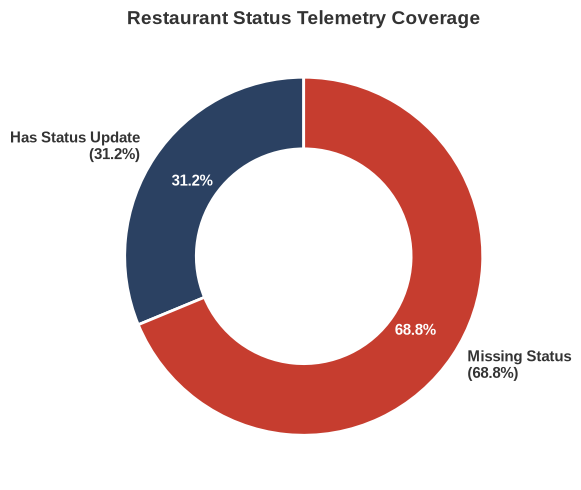


--- SLA Freshness & Coverage Suitability --- 


,Use Case,Required Freshness & Coverage,Suitability
0,Weekly Analytics,Days / End-of-week,WARN. 31% coverage means we can only analyze kitchen bottlenecks for a fraction of our volume.
1,Live Customer ETA,Seconds / Real-time,"FAIL. We are missing status signals entirely for ~69% of orders, and only receiving single snapshots for the rest. We cannot power a liv..."
2,Restaurant Accountability,Minutes,"FAIL. Without a complete time-series of state transitions (e.g., preparing → ready) for the majority of orders, we cannot accurately mea..."



CHALLENGE 5 INSIGHTS: SLA TIMING & FRESHNESS
TIMING & CHRONOLOGY CHECK: 
- Total status updates analyzed: 501 
- Status updates arriving AFTER actual delivery: 0 
Insight: The timestamps for the statuses we *do* receive are chronologically sound (no post-delivery updates). 
------------------------------------------------------------------------------------------------------------------------
COVERAGE CHECK: 
- Total orders: 1597 
- Orders with at least one restaurant status: 499 (31.2%) 
Insight: While the timing of the data is accurate, the volume is catastrophic. Missing telemetry for 69% of our orders 
means this table cannot be trusted for real-time operational decisions. 


In [63]:
# --- 1. DATA PREP & CALCULATIONS ---
# Base population of cleaned orders
clean_orders = orders.drop_duplicates("order_id", keep=False).copy()

# Merge orders with restaurant status updates
status_timing = clean_orders[['order_id', 'created_at', 'actual_delivery_at']].merge(
    restaurant_status, on='order_id', how='left'
)
status_timing['last_updated_at'] = pd.to_datetime(status_timing['last_updated_at'], format='mixed', errors='coerce')

# Analyze Freshness (are updates arriving after the food is already delivered?)
has_update = status_timing[status_timing['status'].notna()].copy()
has_update['updated_after_delivery'] = has_update['last_updated_at'] > has_update['actual_delivery_at']
late_updates = has_update['updated_after_delivery'].sum()
total_updates = len(has_update)

# Analyze Coverage (what percentage of orders have any status update at all?)
total_orders = len(clean_orders)
orders_with_status = has_update['order_id'].nunique()
coverage_pct = orders_with_status / total_orders

# Build SLA Freshness Requirements DataFrame
sla_data = [
    {
        "Use Case": "Weekly Analytics", 
        "Required Freshness & Coverage": "Days / End-of-week", 
        "Suitability": "WARN. 31% coverage means we can only analyze kitchen bottlenecks for a fraction of our volume."
    },
    {
        "Use Case": "Live Customer ETA", 
        "Required Freshness & Coverage": "Seconds / Real-time", 
        "Suitability": "FAIL. We are missing status signals entirely for ~69% of orders, and only receiving single snapshots for the rest. We cannot power a live ETA tracker with this."
    },
    {
        "Use Case": "Restaurant Accountability", 
        "Required Freshness & Coverage": "Minutes", 
        "Suitability": "FAIL. Without a complete time-series of state transitions (e.g., preparing → ready) for the majority of orders, we cannot accurately measure or penalize restaurant prep times."
    }
]
sla_df = pd.DataFrame(sla_data)


# --- 2. VISUAL EXPLANATION (CHART) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Donut chart for coverage
sizes = [orders_with_status, total_orders - orders_with_status]
labels = [f'Has Status Update\n({coverage_pct:.1%})', f'Missing Status\n({1 - coverage_pct:.1%})']
colors = ['#2B4162', '#C63D2F']

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%', pctdistance=0.75,
    startangle=90, textprops={'fontsize': 11, 'weight': 'bold', 'color': '#333333'},
    wedgeprops=dict(width=0.4, edgecolor='#ffffff', linewidth=2)
)

# Style the inner percentage text
for autotext in autotexts:
    autotext.set_color('#ffffff')

ax.set_title('Restaurant Status Telemetry Coverage', color='#333333', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


# --- 3. VISUAL EXPLANATION (DATAFRAME) ---
print("\n--- SLA Freshness & Coverage Suitability --- ")
display(sla_df)


# --- 4. TEXTUAL EXPLANATION (INSIGHTS) ---
print("\n========================================================================================================================")
print("CHALLENGE 5 INSIGHTS: SLA TIMING & FRESHNESS")
print("========================================================================================================================")
print("TIMING & CHRONOLOGY CHECK: ")
print(f"- Total status updates analyzed: {total_updates} ")
print(f"- Status updates arriving AFTER actual delivery: {late_updates} ")
print("Insight: The timestamps for the statuses we *do* receive are chronologically sound (no post-delivery updates). ")
print("------------------------------------------------------------------------------------------------------------------------")
print("COVERAGE CHECK: ")
print(f"- Total orders: {total_orders} ")
print(f"- Orders with at least one restaurant status: {orders_with_status} ({coverage_pct:.1%}) ")
print("Insight: While the timing of the data is accurate, the volume is catastrophic. Missing telemetry for 69% of our orders \nmeans this table cannot be trusted for real-time operational decisions. ")
print("========================================================================================================================")

**SLA Freshness Requirements**
| Use Case | Required Freshness & Coverage | Suitability |
| --- | --- | --- |
| **Weekly Analytics** | Days / End-of-week | **WARN.** 31% coverage means we can only analyze kitchen bottlenecks for a fraction of our volume. |
| **Live Customer ETA** | Seconds / Real-time | **FAIL.** We are missing status signals entirely for ~69% of orders, and only receiving single snapshots for the rest. We cannot power a live ETA tracker with this. |
| **Restaurant Accountability** | Minutes | **FAIL.** Without a complete time-series of state transitions (e.g., preparing → ready) for the majority of orders, we cannot accurately measure or penalize restaurant prep times. |

# Challenge 6 — Build the validation gate


Summarize the investigation:

| Check | Status | Evidence | Action |
| --- | --- | --- | --- |
| Business grain | FAIL | 3 duplicate `order_id` records detected | Require upstream deduplication logic |
| Timestamp chronology | FAIL | 4 promised ETAs logged before creation; 5 pickups logged after delivery | Isolate the write path that derives these fields — the exact, repeated offset points to a formula/config bug, not random clock skew. |
| KPI definition | FAIL | Conflicting logic yields rates of 56.4%, 23.3%, and 52.7% | Force stakeholders to agree on a canonical threshold |
| Category semantics | WARN | Ambiguous distinction between `handoff` and `handed_off` | Clarify state definitions with product owners |
| Cross-source mapping | FAIL | Significant volume of support tickets are missing order_ids entirely | Unsafe to analyze complaint rates by order geography/driver without isolating orphaned tickets.|
| Freshness & Coverage | FAIL | ~31% status coverage (missing for ~69% of orders) and lacks time-series transitions | Unsafe for live ETA tracker; require full telemetry from upstream |

Use only:
**PASS / WARN / FAIL / UNKNOWN**

Finally answer:

> **Should leadership publish “Late Delivery Rate = 56%” today?**

What exactly must happen before the metric becomes publishable?

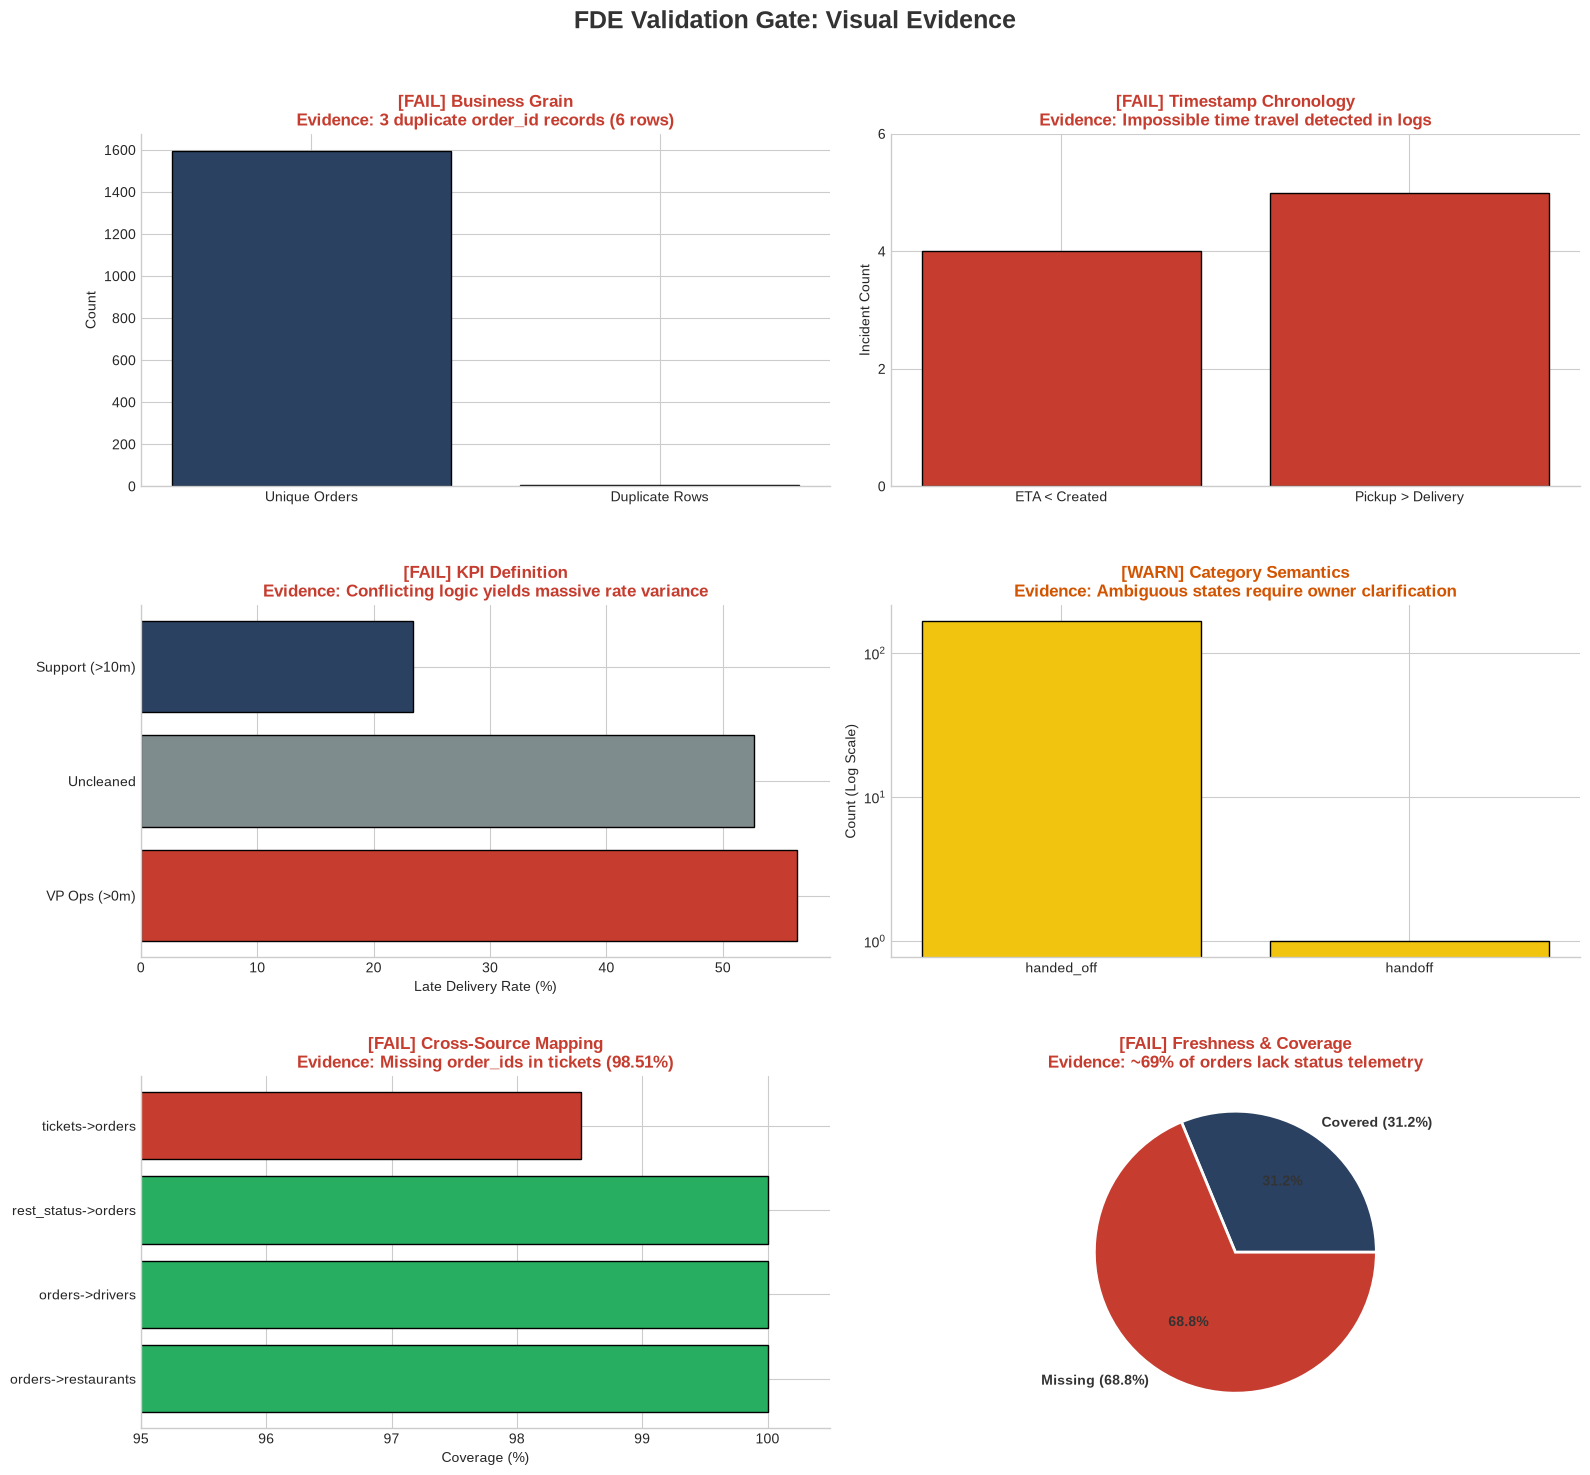

THE VALIDATION GATE: ACTIONS REQUIRED
[FAIL] Business grain         -> Action: Require upstream deduplication logic
[FAIL] Timestamp chronology   -> Action: Isolate the write path that derives these fields
[FAIL] KPI definition         -> Action: Force stakeholders to agree on a canonical threshold
[WARN] Category semantics     -> Action: Clarify state definitions with product owners
[FAIL] Cross-source mapping   -> Action: Unsafe to analyze complaint rates without isolating orphaned tickets
[FAIL] Freshness & Coverage   -> Action: Unsafe for live ETA tracker; require full telemetry from upstream
------------------------------------------------------------------------------------------

FINAL OPERATIONAL CONCLUSION: PUBLISHING THE METRIC
DECISION: FAIL. Leadership MUST NOT publish the 'Late Delivery Rate = 56%' metric today.
------------------------------------------------------------------------------------------
REQUIRED ACTIONS BEFORE PUBLISHING:
1. Resolve Upstream Write Bugs: Engi

In [64]:
# --- 1. PREPARE THE VISUAL EVIDENCE DASHBOARD ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('FDE Validation Gate: Visual Evidence', fontsize=18, fontweight='bold', color='#333333', y=0.98)

PROF_BLUE = '#2B4162'
ERROR_RED = '#C63D2F'
WARN_YELLOW = '#F1C40F'
PASS_GREEN = '#27AE60'

# 1. Business Grain [FAIL]
ax = axes[0, 0]
ax.bar(['Unique Orders', 'Duplicate Rows'], [1597, 6], color=[PROF_BLUE, ERROR_RED], edgecolor='#000000')
ax.set_title('[FAIL] Business Grain\nEvidence: 3 duplicate order_id records (6 rows)', fontweight='bold', color=ERROR_RED)
ax.set_ylabel('Count')

# 2. Timestamp Chronology [FAIL]
ax = axes[0, 1]
ax.bar(['ETA < Created', 'Pickup > Delivery'], [4, 5], color=ERROR_RED, edgecolor='#000000')
ax.set_title('[FAIL] Timestamp Chronology\nEvidence: Impossible time travel detected in logs', fontweight='bold', color=ERROR_RED)
ax.set_ylabel('Incident Count')
ax.set_yticks([0, 2, 4, 6])

# 3. KPI Definition [FAIL]
ax = axes[1, 0]
ax.barh(['VP Ops (>0m)', 'Uncleaned', 'Support (>10m)'], [56.4, 52.7, 23.4], color=[ERROR_RED, '#7f8c8d', PROF_BLUE], edgecolor='#000000')
ax.set_title('[FAIL] KPI Definition\nEvidence: Conflicting logic yields massive rate variance', fontweight='bold', color=ERROR_RED)
ax.set_xlabel('Late Delivery Rate (%)')

# 4. Category Semantics [WARN]
ax = axes[1, 1]
ax.bar(['handed_off', 'handoff'], [168, 1], color=WARN_YELLOW, edgecolor='#000000')
ax.set_title('[WARN] Category Semantics\nEvidence: Ambiguous states require owner clarification', fontweight='bold', color='#d35400')
ax.set_ylabel('Count (Log Scale)')
ax.set_yscale('log')  # Log scale to visually represent 1 vs 168 cleanly

# 5. Cross-Source Mapping [FAIL]
ax = axes[2, 0]
ax.barh(['orders->restaurants', 'orders->drivers', 'rest_status->orders', 'tickets->orders'], 
        [100, 100, 100, 98.51], color=[PASS_GREEN, PASS_GREEN, PASS_GREEN, ERROR_RED], edgecolor='#000000')
ax.set_xlim(95, 100.5)
ax.set_title('[FAIL] Cross-Source Mapping\nEvidence: Missing order_ids in tickets (98.51%)', fontweight='bold', color=ERROR_RED)
ax.set_xlabel('Coverage (%)')

# 6. Freshness & Coverage [FAIL]
ax = axes[2, 1]
ax.pie([499, 1098], labels=['Covered (31.2%)', 'Missing (68.8%)'], colors=[PROF_BLUE, ERROR_RED], autopct='%1.1f%%',
       wedgeprops=dict(edgecolor='#ffffff', linewidth=2), textprops={'weight': 'bold', 'color': '#333333'})
ax.set_title('[FAIL] Freshness & Coverage\nEvidence: ~69% of orders lack status telemetry', fontweight='bold', color=ERROR_RED)

for ax_idx in axes.flat:
    if not isinstance(ax_idx, plt.PolarAxes): # Skip pie chart for spine removal
        ax_idx.spines['top'].set_visible(False)
        ax_idx.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0)
plt.show()


# --- 2. TEXTUAL EXPLANATION (ACTIONS & FINAL DECISION) ---
print("==========================================================================================")
print("THE VALIDATION GATE: ACTIONS REQUIRED")
print("==========================================================================================")
print("[FAIL] Business grain         -> Action: Require upstream deduplication logic")
print("[FAIL] Timestamp chronology   -> Action: Isolate the write path that derives these fields")
print("[FAIL] KPI definition         -> Action: Force stakeholders to agree on a canonical threshold")
print("[WARN] Category semantics     -> Action: Clarify state definitions with product owners")
print("[FAIL] Cross-source mapping   -> Action: Unsafe to analyze complaint rates without isolating orphaned tickets")
print("[FAIL] Freshness & Coverage   -> Action: Unsafe for live ETA tracker; require full telemetry from upstream")
print("------------------------------------------------------------------------------------------")

print("\n==========================================================================================")
print("FINAL OPERATIONAL CONCLUSION: PUBLISHING THE METRIC")
print("==========================================================================================")
print("DECISION: FAIL. Leadership MUST NOT publish the 'Late Delivery Rate = 56%' metric today.")
print("------------------------------------------------------------------------------------------")
print("REQUIRED ACTIONS BEFORE PUBLISHING:")
print("1. Resolve Upstream Write Bugs: Engineering must fix the exact -10 minute ETA and +5 minute pickup timestamp inversions.")
print("2. Deduplicate Grain: Remove duplicate order_ids to prevent volume skewing.")
print("3. Align Stakeholders: The VP of Operations and the Support Lead must formally agree on the mathematical threshold for 'late' (e.g., > 0 mins vs. > 10 mins).")
print("==========================================================================================")
print("FINAL TAKEAWAY:")
print("The job was not to make the data look clean. The job was to decide: Is this data safe enough for this decision, and what remains unresolved?")
print("==========================================================================================")

# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**

> By surfacing upstream write-path bugs, challenging ambiguous KPI definitions, 
and quantifying the exact scope of missing telemetry, we shift the conversation 
from 'Here is your calculated metric' to 'Here is why this metric is currently 
unsafe to publish.'